# Experiment 1: Basic Snowball Setup and Valuation

This notebook demonstrates the basic setup and valuation of Snowball options using the PfHedge library. We'll examine the instrument structure, valuation performance, and computational efficiency.

## What are Snowball Options?

**Snowball options** are exotic derivatives with the following key features:
- **Knock-in barrier**: If the underlying asset touches this barrier, the option is "knocked in"
- **Knock-out barriers**: Regular observation dates where the option can be automatically exercised
- **Coupon payments**: Regular payments if the option is not knocked out
- **Memory feature**: Accumulated coupons are paid if the option is eventually knocked out
- **Path dependency**: The payoff depends on the entire price path, not just the final price

In [1]:
# Import all necessary libraries
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from math import sqrt

# PfHedge imports
from pfhedge.instruments import BrownianStock, Snowball

# Set random seed for reproducibility
torch.manual_seed(42)
print("Snowball valuation experiment loaded successfully!")

Snowball valuation experiment loaded successfully!


Snowball Valuation Analysis
Simulation time: 3.037824 seconds
Payoff calculation time: 0.108496 seconds
Statistics calculation time: 0.002090 seconds
Present Value: 0.049309
Standard Deviation: 0.146632
Standard Error: 0.000147
Simulation time: 3.037824 seconds
Payoff calculation time: 0.108496 seconds
Statistics calculation time: 0.002090 seconds
Present Value: 0.049309
Standard Deviation: 0.146632
Standard Error: 0.000147


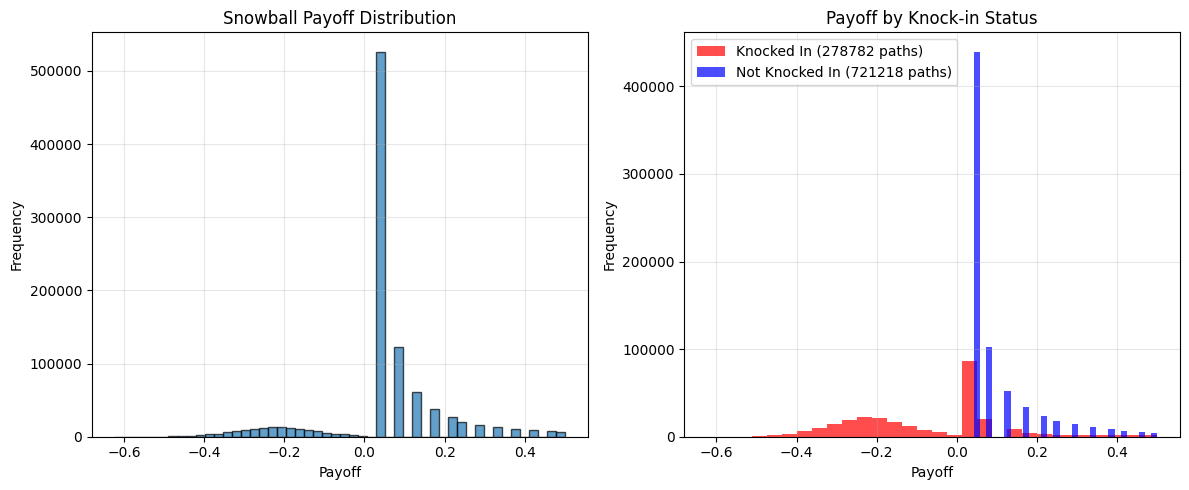

Knock-in probability: 0.2788
Average payoff (knocked in): -0.068033
Average payoff (not knocked in): 0.094667


In [2]:
def create_basic_snowball():
    """Create a basic Snowball option for experimentation."""

    # Market parameters
    init_state = 100.0
    dt = 1 / 250  # Daily time steps
    sigma = 0.2
    mu = 0.0
    cost = 1e-4

    # Underlying stock
    stock = BrownianStock(sigma=sigma, mu=mu, dt=dt, cost=cost)

    # Observation dates (monthly observations over 1 year)
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]

    # Snowball parameters
    derivative = Snowball(
        underlier=stock,
        notional=1.0,
        init_spot=init_state,
        strike=100.0,
        maturity=obs_days[-1] * dt,
        knockin_barrier=80.0,  # 20% below initial spot
        observations=[d * dt for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),  # At-the-money knock-out
        knockout_coupons=[0.5 * d / 250 for d in obs_days],  # Time-proportional coupons
        no_touch_coupon=0.05,  # 5% if never knocked out
        is_knocked_in=False,
    )

    return derivative, stock, init_state

def analyze_snowball_valuation():
    """Analyze Snowball valuation performance."""

    print("Snowball Valuation Analysis")
    print("=" * 50)

    derivative, stock, init_state = create_basic_snowball()

    # Valuation with Monte Carlo
    pv_n_paths = 1000000
    init_spot = torch.tensor(init_state, requires_grad=True)

    # Simulation timing
    start_time = time.time()
    derivative.simulate(n_paths=pv_n_paths, init_state=(init_spot,))
    simulation_time = time.time() - start_time

    # Payoff calculation timing
    start_time = time.time()
    payoff = derivative.payoff()
    payoff_time = time.time() - start_time

    # Statistics calculation
    start_time = time.time()
    pv = payoff.mean()
    stddev = payoff.std()
    stats_time = time.time() - start_time

    # Print results
    print(f"Simulation time: {simulation_time:.6f} seconds")
    print(f"Payoff calculation time: {payoff_time:.6f} seconds")
    print(f"Statistics calculation time: {stats_time:.6f} seconds")
    print(f"Present Value: {pv.item():.6f}")
    print(f"Standard Deviation: {stddev.item():.6f}")
    print(f"Standard Error: {stddev.item() / sqrt(pv_n_paths):.6f}")

    # Payoff distribution analysis
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(payoff.detach().numpy(), bins=50, alpha=0.7, edgecolor='black')
    plt.title("Snowball Payoff Distribution")
    plt.xlabel("Payoff")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)

    # Analyze knock-in scenarios
    knocked_in_paths = derivative.knocked_in()[..., -1].squeeze()  # Get final knock-in status
    knocked_in_payoffs = payoff[knocked_in_paths]
    not_knocked_in_payoffs = payoff[~knocked_in_paths]

    plt.subplot(1, 2, 2)
    if len(knocked_in_payoffs) > 0:
        plt.hist(knocked_in_payoffs.detach().numpy(), bins=30, alpha=0.7,
                label=f'Knocked In ({len(knocked_in_payoffs)} paths)', color='red')
    if len(not_knocked_in_payoffs) > 0:
        plt.hist(not_knocked_in_payoffs.detach().numpy(), bins=30, alpha=0.7,
                label=f'Not Knocked In ({len(not_knocked_in_payoffs)} paths)', color='blue')
    plt.title("Payoff by Knock-in Status")
    plt.xlabel("Payoff")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Knock-in probability: {knocked_in_paths.float().mean():.4f}")
    print(f"Average payoff (knocked in): {knocked_in_payoffs.mean():.6f}" if len(knocked_in_payoffs) > 0 else "No knock-in paths")
    print(f"Average payoff (not knocked in): {not_knocked_in_payoffs.mean():.6f}" if len(not_knocked_in_payoffs) > 0 else "All paths knocked in")

    return derivative, pv.item()

# Run basic valuation analysis
derivative_basic, pv_basic = analyze_snowball_valuation()

## Key Insights from Snowball Valuation

### Performance Metrics
- **Computational Efficiency**: The simulation and payoff calculation provide timing benchmarks
- **Statistical Accuracy**: Standard error shows the precision of Monte Carlo estimation
- **Path Dependency**: Clear distinction between knocked-in and non-knocked-in scenarios

### Structural Features
- **Knock-in Probability**: Shows how often the barrier is breached
- **Payoff Distribution**: Bimodal distribution reflecting barrier structure
- **Risk Profile**: Different risk characteristics based on knock-in status

This experiment establishes the foundation for understanding Snowball options and their complex payoff structures, which is essential for developing effective hedging strategies.